# Домашнее задание 2: решение

Решение оформлено как ноутбук: теоретические выводы написаны в markdown, а графики и численные значения пересчитываются в кодовых ячейках. Формулировка задания лежит в `/Users/maria/Desktop/work/HSE/additional/hse_githubs/Time series/2026-spring/homeworks/hw2/hw2.pdf`.

Материалы курса, на которые я опираюсь:
- определения белого шума, слабой стационарности и ACF из первого семинара;
- лаговые операторы, стационарные AR-представления и импульсные отклики;
- ETS как state-space модель из лекции и семинара по ETS;
- рекурсии условной дисперсии для GARCH/IGARCH.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 4)
pd.options.display.float_format = "{:,.4f}".format


## Задача 1. Белый шум $Z_t=b_tX_t$

Проверяем три свойства белого шума в курсовом смысле: нулевое среднее, постоянная конечная дисперсия и нулевая автоковариация.

Пусть

$$
X_t =
\begin{cases}
+1, & \text{с вероятностью } p,\\
-1, & \text{с вероятностью } 1-p.
\end{cases}
$$

Тогда

$$
\mathbb E X_t = p-(1-p)=2p-1.
$$

Так как $b_t>0$ и $b_t$ измерима относительно прошлого $\mathcal F_{t-1}$, условное среднее равно

$$
\mathbb E(Z_t\mid \mathcal F_{t-1})
= b_t\mathbb E X_t
= b_t(2p-1).
$$

Чтобы среднее было нулевым при любой ставке, нужно и достаточно

$$
\boxed{p=\frac12.}
$$


In [2]:
p_grid = np.array([0.25, 0.50, 0.75])
b = 3

demo = pd.DataFrame(
    {
        "p": p_grid,
        "E[X_t]": 2 * p_grid - 1,
        "E[Z_t] with b=3": b * (2 * p_grid - 1),
        "Var[Z_t] with b=3 and p=1/2 only": [np.nan, b**2, np.nan],
    }
)
display(demo)


,p,E[X_t],E[Z_t] with b=3,Var[Z_t] with b=3 and p=1/2 only
0,0.2500,-0.5000,-1.5000,NaN
1,0.5000,0.0000,0.0000,9.0000
2,0.7500,0.5000,1.5000,NaN


При $p=1/2$ имеем $X_t^2=1$ и $\mathrm{Var}(X_t)=1$. Поэтому условная дисперсия выигрыша:

$$
\mathrm{Var}(Z_t\mid \mathcal F_{t-1}) = b_t^2.
$$

Если стратегия адаптивная и реально меняет размер ставки от истории, то условная дисперсия становится переменной. Это дает мартингальную разность, но не гомоскедастический белый шум в стандартном определении курса.

Чтобы дисперсия была постоянной, требуется

$$
\boxed{b_t=b=\mathrm{const}.}
$$

При $p=1/2$ и постоянном $b$ автоковариации равны нулю, потому что исходы $X_t$ независимы:

$$
\mathrm{Cov}(Z_t,Z_{t+k})=b^2\mathrm{Cov}(X_t,X_{t+k})=0,\quad k\neq0.
$$

Итог:

$$
\boxed{\{Z_t\}\sim WN(0,b^2)\Longleftrightarrow p=\frac12,\ b_t=b=\mathrm{const}.}
$$

Небольшая оговорка: если использовать более слабое определение через безусловные моменты, то можно обсуждать случай $\mathbb E b_t^2=\mathrm{const}<\infty$. Но в логике этого курса и задания требуется именно постоянная дисперсия потока выигрышей, поэтому адаптивная переменная ставка не подходит.


## Задача 2. AR(1), $0<\varphi<1$

Рассматриваем

$$
y_t=\varphi y_{t-1}+\varepsilon_t,\qquad 0<\varphi<1,
$$

где $\varepsilon_t$ - белый шум с нулевым средним и дисперсией $\sigma^2$.

### (a) Стационарное решение

В лаговой форме:

$$
(1-\varphi L)y_t=\varepsilon_t.
$$

Так как $|\varphi|<1$, оператор обратим назад:

$$
(1-\varphi L)^{-1}=1+\varphi L+\varphi^2L^2+\ldots
$$

Поэтому

$$
\boxed{y_t=\sum_{j=0}^{\infty}\varphi^j\varepsilon_{t-j}.}
$$

Моменты:

$$
\mathbb E y_t=0,\qquad
\mathrm{Var}(y_t)=\sigma^2\sum_{j=0}^{\infty}\varphi^{2j}
=\boxed{\frac{\sigma^2}{1-\varphi^2}}.
$$


### (b) Одиночный шок

Если в момент $T$ шок увеличился на единицу,

$$
\varepsilon_T\to \varepsilon_T+1,
$$

то в MA($\infty$)-представлении этот шок входит в $y_{T+h}$ с коэффициентом $\varphi^h$:

$$
\boxed{\Delta_h=\varphi^h,\qquad h=0,1,2,\ldots}
$$

Так как $0<\varphi<1$, эффект геометрически затухает к нулю.


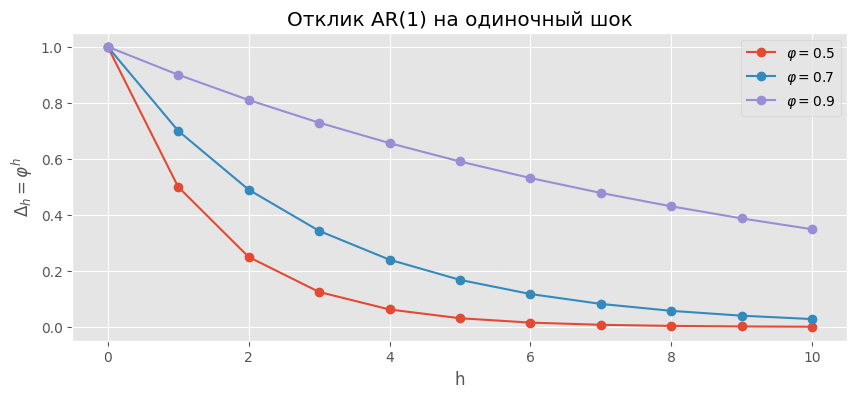

In [3]:
phi_values = [0.5, 0.7, 0.9]
horizon = np.arange(0, 11)

fig, ax = plt.subplots(figsize=(10, 4))
for phi in phi_values:
    ax.plot(horizon, phi**horizon, marker="o", label=fr"$\varphi={phi}$")
ax.set_title("Отклик AR(1) на одиночный шок")
ax.set_xlabel("h")
ax.set_ylabel(r"$\Delta_h=\varphi^h$")
ax.legend()
plt.show()


### (c) Постоянный сдвиг шоков

Теперь каждый шок после $T$ увеличивается на единицу:

$$
\varepsilon_t\to \varepsilon_t+1,\qquad t\ge T.
$$

Эффект на $y_{T+h}$ равен сумме одиночных откликов:

$$
\Gamma_h=\sum_{k=0}^{h}\varphi^k
=\boxed{\frac{1-\varphi^{h+1}}{1-\varphi}}.
$$

Предел:

$$
\boxed{\lim_{h\to\infty}\Gamma_h=\frac{1}{1-\varphi}.}
$$

Это долгосрочный мультипликатор AR(1): чем ближе $\varphi$ к единице, тем дольше живет эффект и тем больше предельный сдвиг.


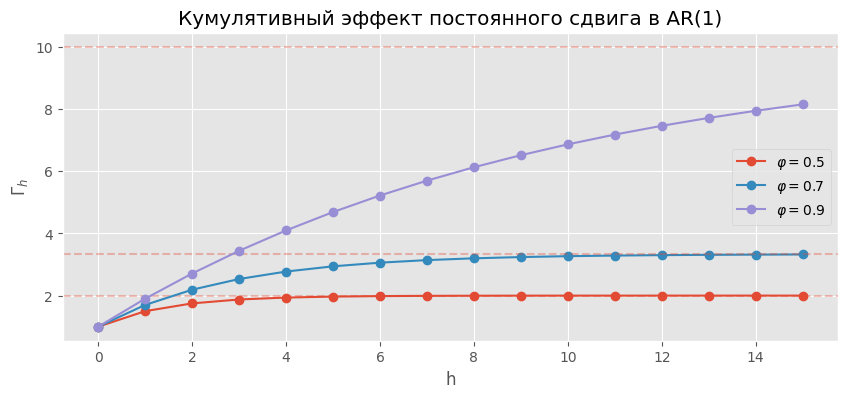

In [4]:
horizon = np.arange(0, 16)

fig, ax = plt.subplots(figsize=(10, 4))
for phi in phi_values:
    gamma_h = (1 - phi ** (horizon + 1)) / (1 - phi)
    ax.plot(horizon, gamma_h, marker="o", label=fr"$\varphi={phi}$")
    ax.axhline(1 / (1 - phi), linestyle="--", alpha=0.35)
ax.set_title("Кумулятивный эффект постоянного сдвига в AR(1)")
ax.set_xlabel("h")
ax.set_ylabel(r"$\Gamma_h$")
ax.legend()
plt.show()


## Задача 3. AR(1) с константой, $|\varphi|>1$

Рассматриваем

$$
y_t=c+\varphi y_{t-1}+\varepsilon_t,\qquad |\varphi|>1.
$$

### (a) Стационарное решение

В лаговой форме:

$$
(1-\varphi L)y_t=c+\varepsilon_t.
$$

При $|\varphi|>1$ привычная инверсия назад расходится. Нужно инвертировать оператор вперед:

$$
1-\varphi L=-\varphi L(1-\varphi^{-1}F),
$$

где $F=L^{-1}$ - оператор сдвига вперед. Тогда

$$
(1-\varphi L)^{-1}
=-\sum_{k=1}^{\infty}\varphi^{-k}F^k.
$$

Применяем это к $c+\varepsilon_t$:

$$
y_t
=-\sum_{k=1}^{\infty}\varphi^{-k}(c+\varepsilon_{t+k})
=\frac{c}{1-\varphi}-\sum_{k=1}^{\infty}\varphi^{-k}\varepsilon_{t+k}.
$$

Ответ:

$$
\boxed{y_t=\frac{c}{1-\varphi}-\sum_{k=1}^{\infty}\varphi^{-k}\varepsilon_{t+k}.}
$$

Это стационарное, но некаузальное решение: оно записано через будущие шоки.


Проверка моментов:

$$
\mathbb E y_t=\frac{c}{1-\varphi},
$$

$$
\mathrm{Var}(y_t)
=\sigma^2\sum_{k=1}^{\infty}\varphi^{-2k}
=\frac{\sigma^2}{\varphi^2-1},
$$

$$
\gamma(h)=\mathrm{Cov}(y_t,y_{t-h})
=\frac{\sigma^2\varphi^{-|h|}}{\varphi^2-1}.
$$

Среднее постоянно, дисперсия конечна, автоковариация зависит только от лага. Значит, найденное решение слабо стационарно.

### (b) Разложение Вольда

Разложение из пункта (a) не является Вольдовым относительно исходных $\varepsilon_t$, потому что использует будущие шоки. Это важный момент: при $|\varphi|>1$ нет каузального MA($\infty$)-представления через тот же шум $\varepsilon_t$.

Но сам стационарный процесс имеет Вольдово разложение через инновации из прошлого. Обозначим

$$
\mu=\frac{c}{1-\varphi},\qquad x_t=y_t-\mu.
$$

Так как автоковариационная функция совпадает с каузальным AR(1) с коэффициентом $\rho=1/\varphi$, можно записать:

$$
x_t=\frac{1}{\varphi}x_{t-1}+\eta_t,
\qquad
\eta_t\sim WN\left(0,\frac{\sigma^2}{\varphi^2}\right).
$$

Значит,

$$
y_t=\mu+\sum_{j=0}^{\infty}\left(\frac{1}{\varphi}\right)^j\eta_{t-j}.
$$

Вольдово разложение:

$$
\boxed{
d_t=\mu=\frac{c}{1-\varphi},\qquad
\psi_j=\varphi^{-j},\qquad
\eta_t\sim WN\left(0,\frac{\sigma^2}{\varphi^2}\right).
}
$$

Смысл: исходное уравнение с $|\varphi|>1$ стационарно только в некаузальной записи через будущие $\varepsilon$, а Вольдово разложение существует через другой белый шум - инновации $\eta_t$.


## Задача 4. ETS$(A,A_d,N)$

Дана модель:

$$
y_t=l_{t-1}+\phi b_{t-1}+\varepsilon_t,
$$

$$
l_t=l_{t-1}+\phi b_{t-1}+\alpha\varepsilon_t,
$$

$$
b_t=\phi b_{t-1}+\beta\varepsilon_t,
$$

где $\varepsilon_t\sim N(0,\sigma^2)$.

Параметры:

$$
\alpha=0.4,\quad \beta=0.2,\quad \phi=0.5,\quad \sigma^2=4,\quad l_T=100,\quad b_T=10.
$$

### (a) Точечный прогноз

Так как будущие ошибки имеют нулевое условное среднее,

$$
\widehat y_{T+h|T}
=l_T+\left(\sum_{i=1}^{h}\phi^i\right)b_T
=l_T+\phi\frac{1-\phi^h}{1-\phi}b_T.
$$

Для $h=3$:

$$
\widehat y_{T+3|T}=100+(0.5+0.25+0.125)\cdot10
=\boxed{108.75}.
$$

Предел:

$$
\lim_{h\to\infty}\widehat y_{T+h|T}
=l_T+\frac{\phi}{1-\phi}b_T
=\boxed{110}.
$$


### (b) Дисперсия ошибки прогноза

Ошибка $h$-шагового прогноза раскладывается по будущим инновациям:

$$
e_h=y_{T+h}-\widehat y_{T+h|T}
=\varepsilon_{T+h}+\sum_{j=1}^{h-1}c_j\varepsilon_{T+h-j}.
$$

Коэффициенты:

$$
c_j=\alpha+\beta\sum_{i=1}^{j}\phi^i
=\alpha+\frac{\beta\phi(1-\phi^j)}{1-\phi}.
$$

При наших параметрах:

$$
c_j=0.6-0.2\cdot0.5^j.
$$

Для $h=3$ нужны $c_1=0.5$ и $c_2=0.55$, поэтому

$$
\sigma_3^2
=4(1+c_1^2+c_2^2)
=4(1+0.25+0.3025)
=\boxed{6.21}.
$$

Так как $c_j\to0.6\ne0$, дисперсия ошибки прогноза расходится:

$$
\boxed{\sigma_h^2\to\infty.}
$$


### (c) 95% интервальный прогноз

$$
\sigma_3=\sqrt{6.21}\approx2.492.
$$

Нормальный 95% интервал:

$$
108.75\pm1.96\cdot2.492.
$$

Получаем

$$
\boxed{[103.87;\ 113.63].}
$$


In [5]:
alpha = 0.4
beta = 0.2
phi = 0.5
sigma2 = 4
l_T = 100
b_T = 10
h = 3

point_forecast = l_T + sum(phi**i for i in range(1, h + 1)) * b_T
long_run_forecast = l_T + phi / (1 - phi) * b_T

c = {
    j: alpha + beta * sum(phi**i for i in range(1, j + 1))
    for j in range(1, h)
}
forecast_error_variance = sigma2 * (1 + sum(value**2 for value in c.values()))
forecast_error_std = np.sqrt(forecast_error_variance)
interval = (
    point_forecast - 1.96 * forecast_error_std,
    point_forecast + 1.96 * forecast_error_std,
)

display(
    pd.DataFrame(
        {
            "quantity": [
                "point forecast h=3",
                "long-run point forecast",
                "variance h=3",
                "std h=3",
                "lower 95%",
                "upper 95%",
            ],
            "value": [
                point_forecast,
                long_run_forecast,
                forecast_error_variance,
                forecast_error_std,
                interval[0],
                interval[1],
            ],
        }
    )
)
display(pd.DataFrame({"j": list(c), "c_j": list(c.values())}))


,quantity,value
0,point forecast h=3,108.7500
1,long-run point forecast,110.0000
2,variance h=3,6.2100
3,std h=3,2.4920
4,lower 95%,103.8657
5,upper 95%,113.6343


,j,c_j
0,1,0.5000
1,2,0.5500


## Задача 5. GARCH(1,1) и IGARCH

Дана модель:

$$
y_t=\sigma_t\varepsilon_t,\qquad \varepsilon_t\sim WN(0,1),
$$

$$
\sigma_t^2=\omega+\alpha y_{t-1}^2+\beta\sigma_{t-1}^2.
$$

Параметры:


| model   |   omega |   alpha |   beta |   alpha_plus_beta | unconditional_variance   |
|:--------|--------:|--------:|-------:|------------------:|:-------------------------|
| A       |       2 |     0.3 |    0.6 |               0.9 | 20                       |
| B       |       2 |     0.3 |    0.7 |               1   | $\infty$                 |



Начальное условие:

$$
\sigma_T^2=5.
$$

### (a) Безусловная дисперсия

В стационарном GARCH(1,1):

$$
\bar\sigma^2
=\omega+(\alpha+\beta)\bar\sigma^2,
$$

откуда

$$
\boxed{\bar\sigma^2=\frac{\omega}{1-\alpha-\beta}}.
$$

Модель A:

$$
\bar\sigma_A^2=\frac{2}{1-0.3-0.6}=20.
$$

Модель B:

$$
\alpha+\beta=1,
$$

поэтому знаменатель равен нулю. Это IGARCH: конечной безусловной дисперсии нет.


### (b) $h$-шаговый прогноз

Для прогноза условной дисперсии используем рекурсию

$$
f_h=\mathbb E(\sigma_{T+h}^2\mid\mathcal F_T),
\qquad
f_h=\omega+(\alpha+\beta)f_{h-1},
\qquad
f_0=\sigma_T^2.
$$

Если $\alpha+\beta<1$, то

$$
f_h=\bar\sigma^2+(\sigma_T^2-\bar\sigma^2)(\alpha+\beta)^h.
$$

Для модели A:

$$
\boxed{f_h^A=20-15\cdot0.9^h.}
$$

Для модели B, где $\alpha+\beta=1$:

$$
\boxed{f_h^B=5+2h.}
$$

Численные значения:


| model   |   1 |      5 |     20 |
|:--------|----:|-------:|-------:|
| A       | 6.5 | 11.143 | 18.176 |
| B       | 7   | 15     | 45     |



### (c) Пределы

Модель A:

$$
\boxed{f_h^A\to20.}
$$

То есть волатильность mean-reverting: прогноз возвращается к долгосрочному уровню.

Модель B:

$$
\boxed{f_h^B\to\infty.}
$$

Это турбулентный IGARCH-сценарий: равновесного уровня волатильности нет, неопределенность на горизонте растет без ограничения.


### (d) Эффект большого шока

Если $y_T^2$ увеличился на 1 сверх ожидаемого, то в прогноз $f_1$ это входит через слагаемое $\alpha y_T^2$. Дальше эффект каждый шаг умножается на $\alpha+\beta$:

$$
\boxed{\delta_h=\alpha(\alpha+\beta)^{h-1}.}
$$

Модель A:

$$
\delta_h^A=0.3\cdot0.9^{h-1}\to0.
$$

Модель B:

$$
\delta_h^B=0.3\quad\text{для всех }h.
$$

Численные значения:


| model   |   1 |    2 |     5 |   \infty |
|:--------|----:|-----:|------:|---------:|
| A       | 0.3 | 0.27 | 0.197 |      0   |
| B       | 0.3 | 0.3  | 0.3   |      0.3 |



Интерпретация: в модели A рынок постепенно переваривает шок, а в модели B эффект шока не затухает из-за единичного корня в динамике условной дисперсии.


,model,omega,alpha,beta,alpha_plus_beta,unconditional_variance
0,A,2.0000,0.3000,0.6000,0.9000,20.0000
1,B,2.0000,0.3000,0.7000,1.0000,inf


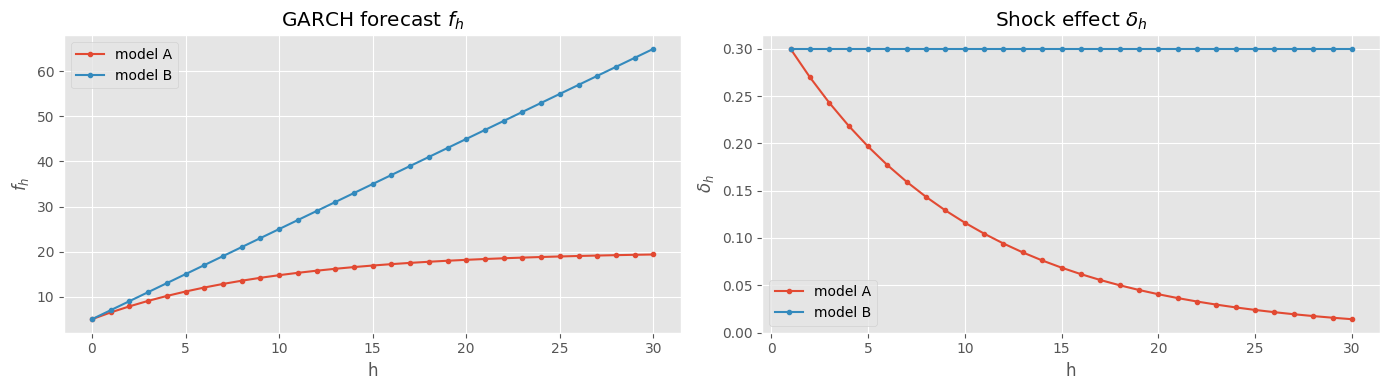

,model,h,f_h
0,A,1,6.5000
1,A,5,11.1426
2,A,20,18.1764
3,B,1,7.0000
4,B,5,15.0000
5,B,20,45.0000


,model,h,delta_h
0,A,1,0.3000
1,A,2,0.2700
2,A,5,0.1968
3,A,inf,0.0000
4,B,1,0.3000
5,B,2,0.3000
6,B,5,0.3000
7,B,inf,0.3000


In [6]:
garch_params = pd.DataFrame(
    [
        {"model": "A", "omega": 2.0, "alpha": 0.3, "beta": 0.6},
        {"model": "B", "omega": 2.0, "alpha": 0.3, "beta": 0.7},
    ]
)
garch_params["alpha_plus_beta"] = garch_params["alpha"] + garch_params["beta"]
garch_params["unconditional_variance"] = np.where(
    garch_params["alpha_plus_beta"] < 1,
    garch_params["omega"] / (1 - garch_params["alpha_plus_beta"]),
    np.inf,
)
display(garch_params)

sigma2_T = 5.0
h_grid = np.arange(0, 31)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for _, row in garch_params.iterrows():
    rho = row["alpha_plus_beta"]
    if rho < 1:
        f_h = row["unconditional_variance"] + (sigma2_T - row["unconditional_variance"]) * rho**h_grid
    else:
        f_h = sigma2_T + row["omega"] * h_grid
    delta_h = row["alpha"] * rho ** np.maximum(h_grid - 1, 0)
    delta_h[0] = np.nan
    axes[0].plot(h_grid, f_h, marker="o", markersize=3, label=f"model {row['model']}")
    axes[1].plot(h_grid, delta_h, marker="o", markersize=3, label=f"model {row['model']}")

axes[0].set_title(r"GARCH forecast $f_h$")
axes[0].set_xlabel("h")
axes[0].set_ylabel(r"$f_h$")
axes[0].legend()

axes[1].set_title(r"Shock effect $\delta_h$")
axes[1].set_xlabel("h")
axes[1].set_ylabel(r"$\delta_h$")
axes[1].legend()

plt.tight_layout()
plt.show()

forecast_table = []
shock_table = []
for _, row in garch_params.iterrows():
    rho = row["alpha_plus_beta"]
    for h in [1, 5, 20]:
        if rho < 1:
            value = row["unconditional_variance"] + (sigma2_T - row["unconditional_variance"]) * rho**h
        else:
            value = sigma2_T + row["omega"] * h
        forecast_table.append({"model": row["model"], "h": h, "f_h": value})
    for h in [1, 2, 5]:
        shock_table.append({"model": row["model"], "h": h, "delta_h": row["alpha"] * rho ** (h - 1)})
    shock_table.append({"model": row["model"], "h": "inf", "delta_h": 0.0 if rho < 1 else row["alpha"]})

display(pd.DataFrame(forecast_table))
display(pd.DataFrame(shock_table))


## Итог

В этой домашней работе главная связка идей такая:
- белый шум требует нулевого среднего, постоянной дисперсии и отсутствия автоковариации;
- AR(1) с $|\varphi|<1$ имеет каузальное стационарное MA($\infty$)-решение и затухающие импульсные отклики;
- AR(1) с $|\varphi|>1$ может иметь стационарное решение, но оно некаузальное относительно исходных шоков;
- damped ETS имеет конечный предел точечного прогноза, но в данной спецификации дисперсия ошибки растет без ограничения;
- GARCH с $\alpha+\beta<1$ возвращается к долгосрочной дисперсии, а IGARCH с $\alpha+\beta=1$ накапливает шоки перманентно.
